## Build a basic chatbot with LangGraph

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(state_schema = State)

In [5]:
import os
from dotenv import load_dotenv, find_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq 

llm = ChatGroq(model='openai/gpt-oss-120b')

In [5]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [8]:
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()

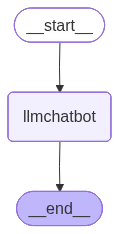

In [9]:
graph

In [12]:
response = graph.invoke({"messages":"Hi"})

In [17]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='48b6df2a-1f8a-4a48-87bb-aca4e71d85a8'),
 AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond with a friendly greeting, maybe ask how can help. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_time': 0.100898044, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.002673536, 'prompt_tokens_details': None, 'queue_time': 0.006469139, 'total_time': 0.10357158}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46d8af1c62', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cf9fa-f597-7fb2-bda1-e988ba247af8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 44, 'total_tokens': 116, 'output_token_details': {'reas

In [20]:
for event in graph.stream({"messages":"What's up, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hey there! I'm doing great, thanks for asking. How can I help you today?


In [23]:
response = graph.invoke({"messages":"Hi please provide me with the latest news"})
response["messages"][-1].content

'I’m not able to browse the web or pull in real‑time information, so I can’t provide today’s breaking headlines. However, I can give you a quick overview of the major trends and storylines that were shaping the news up through mid‑2024, and I’ll point you to reliable sources where you can find the most current updates.\n\n---\n\n## Global Highlights (up to June\u202f2024)\n\n| Region / Topic | Key Developments |\n|----------------|------------------|\n| **United States** | • **2024 presidential election** cycle is in full swing, with the Democratic and Republican primaries shaping the field for the November vote.<br>• **Economic outlook**: Inflation has moderated but remains above the Fed’s 2\u202f% target; the labor market stays tight, and the Federal Reserve is signaling a pause on rate hikes.<br>• **Tech & AI**: Ongoing debates over AI regulation, with the White House releasing a “Blueprint for an AI Bill of Rights” and Congress considering the AI Innovation Act. |\n| **Europe** | •

### chatbot with tool(!)

In [9]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'response_time': 0.63,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph ? - Hugging Face Agents Course',
   'content': '# What is LangGraph ? `LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? ## When should I use LangGraph ? `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your application involves a series of steps that need to be orchestrated in a specific way, with decisions being made at each junction

In [18]:
def multiply(a:int,b:int)-> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [21]:
tools = [tool,multiply]

In [22]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x111e9e510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x111e9f230>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search

In [23]:
## stategraph
from langgraph.prebuilt import ToolNode,tools_condition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools",END)
graph = builder.compile()

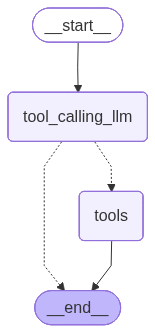

In [24]:
graph

In [25]:
graph.invoke({"messages":"what is the recent UTS news?"})

{'messages': [HumanMessage(content='what is the recent UTS news?', additional_kwargs={}, response_metadata={}, id='99b9f127-b4fd-49b7-8169-24ca3c6cfc8c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "what is the recent UTS news?" Likely University of Technology Sydney (UTS). Need recent news. Use search.', 'tool_calls': [{'id': 'fc_3e4412aa-77ab-4a1f-b9b8-c7731873b3b1', 'function': {'arguments': '{"query":"University of Technology Sydney recent news March 2026","search_depth":"advanced","time_range":"month"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 350, 'total_tokens': 434, 'completion_time': 0.179865039, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.016638928, 'prompt_tokens_details': None, 'queue_time': 0.180871268, 'total_time': 0.196503967}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a42825ac', 'service_tier': 'on_

In [27]:
response = graph.invoke({"messages":"What is 212 multiplied by 3?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 212 multiplied by 3?
================================== Ai Message ==================================

212 × 3 = 636.
